            medalist_name                  Sport   Medal Gender
0            Bair Badënov                archery  bronze   male
1           Ilario Di Buò                archery  silver   male
2            Im Dong-hyun                archery    gold   male
3               Jiang Lin                archery  bronze   male
4          Lee Chang-hwan                archery    gold   male
...                   ...                    ...     ...    ...
1870        Steeve Guénot  greco-roman wrestling    gold   male
1871  Yannick Szczepaniak  greco-roman wrestling  bronze   male
1872       Yavor Yanakiev  greco-roman wrestling  bronze   male
1873      Yury Patrikeyev  greco-roman wrestling  bronze   male
1874         Zoltán Fodor  greco-roman wrestling  silver   male

[1875 rows x 4 columns]


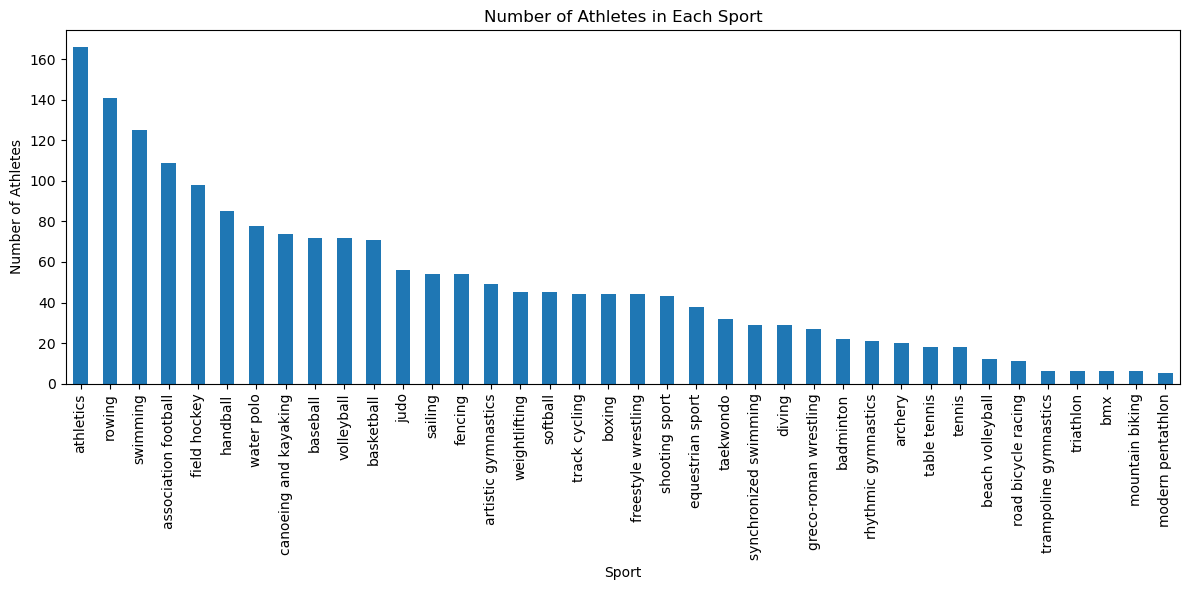

Gender
male      1032
female     843
Name: count, dtype: int64


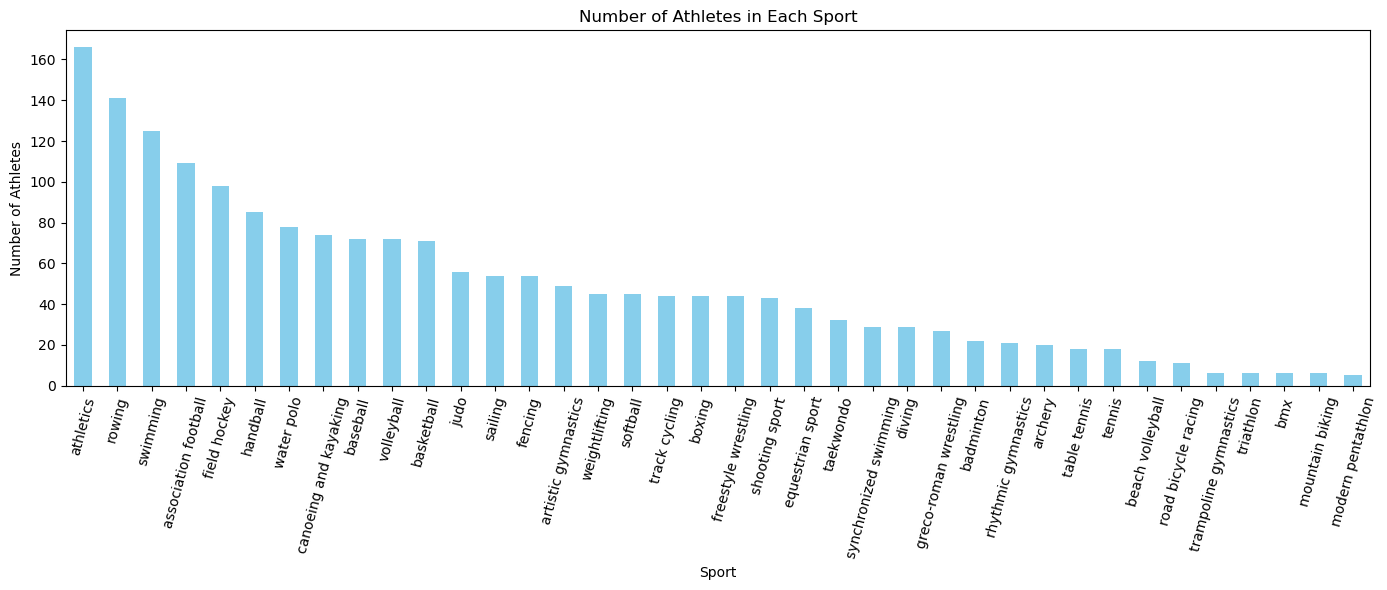

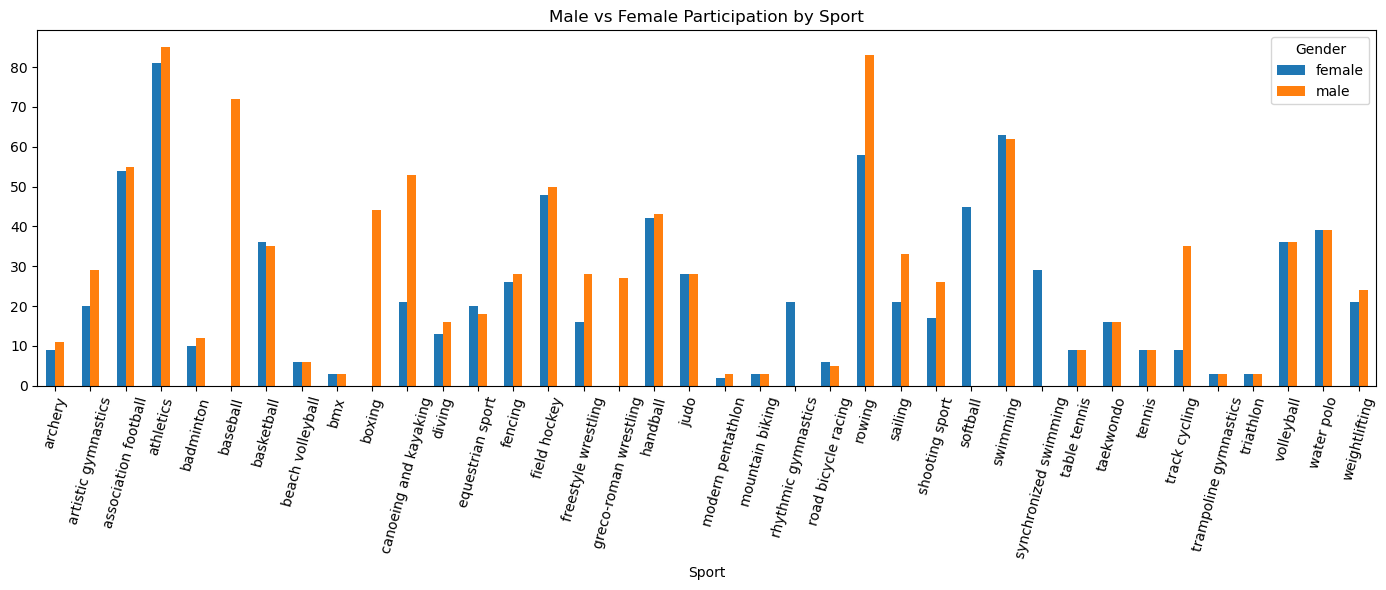

Gender                 female  male
Sport                              
archery                     9    11
artistic gymnastics        20    29
association football       54    55
athletics                  81    85
badminton                  10    12
baseball                    0    72
basketball                 36    35
beach volleyball            6     6
bmx                         3     3
boxing                      0    44
canoeing and kayaking      21    53
diving                     13    16
equestrian sport           20    18
fencing                    26    28
field hockey               48    50
freestyle wrestling        16    28
greco-roman wrestling       0    27
handball                   42    43
judo                       28    28
modern pentathlon           2     3
mountain biking             3     3
rhythmic gymnastics        21     0
road bicycle racing         6     5
rowing                     58    83
sailing                    21    33
shooting sport             1

In [14]:
import pandas as pd

# Use the read_csv function to load the data into a DataFrame
# Ensure the path to your CSV file is correct (relative or absolute)
df = pd.read_csv('olympics_08_medalists.csv') 

# Display the first few rows of the DataFrame (useful in a Jupyter Notebook)

df_melted = pd.melt(df, id_vars=['medalist_name'],
                             value_vars=['male_archery','female_archery','male_athletics','female_athletics','male_badminton','female_badminton','male_baseball','male_basketball','female_basketball','male_boxing','male_canoeing and kayaking','female_canoeing and kayaking','male_road bicycle racing','female_road bicycle racing','male_track cycling','female_track cycling','male_mountain biking','female_mountain biking','male_bmx','female_bmx','male_diving','female_diving','female_equestrian sport','male_equestrian sport','male_fencing','female_fencing','male_field hockey','female_field hockey','male_association football','female_association football','male_artistic gymnastics','female_artistic gymnastics','female_rhythmic gymnastics','male_trampoline gymnastics','female_trampoline gymnastics','male_handball','female_handball','male_judo','female_judo','male_modern pentathlon','female_modern pentathlon','male_rowing','female_rowing','male_sailing','female_sailing','male_shooting sport','female_shooting sport','female_softball','male_swimming','female_swimming','female_synchronized swimming','male_table tennis','female_table tennis','male_taekwondo','female_taekwondo','male_tennis','female_tennis','male_triathlon','female_triathlon','male_beach volleyball','female_beach volleyball','male_volleyball','female_volleyball','male_water polo','female_water polo','male_weightlifting','female_weightlifting','male_freestyle wrestling','female_freestyle wrestling','male_greco-roman wrestling'],
                             var_name='Sport', value_name='Medal')


df_melted = df_melted.dropna(subset=['Medal'])
df_melted = df_melted.reset_index(drop=True)

df_melted[['Gender', 'Sport']] = df_melted['Sport'].str.split('_', n=1, expand=True)


print(df_melted)

sport_counts = df_melted['Sport'].value_counts()

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sport_counts.plot(kind='bar')

plt.title('Number of Athletes in Each Sport')
plt.xlabel('Sport')
plt.ylabel('Number of Athletes')

plt.xticks(rotation=90)  # rotate labels so they fit
plt.tight_layout()

plt.show()

gender_counts = df_melted['Gender'].value_counts()
print(gender_counts)

plt.figure(figsize=(14, 6))
sport_counts.plot(kind='bar', color='skyblue')

plt.title('Number of Athletes in Each Sport')
plt.xlabel('Sport')
plt.ylabel('Number of Athletes')

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

gender_sport_counts = df_melted.groupby(['Sport', 'Gender']).size().unstack(fill_value=0)

gender_sport_counts.plot(kind='bar', figsize=(14, 6))
plt.title('Male vs Female Participation by Sport')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


pivot_table = pd.pivot_table(
    df_melted,
    index='Sport',
    columns='Gender',
    values='Medal',
    aggfunc='count',
    fill_value=0
)

print(pivot_table)